# Computer Vision 1: Assignment 4

Task 3

Group Number 43

Marek Drwal

12.01.2026

## setup

In [1]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

## defs

In [2]:
def show_img(img, pth='', comment='', show=True):
    plt.imshow(img)
    plt.title(comment +' ' + pth)
    if show:
        plt.show()

In [3]:
def load_display_img(pth):
    img = ski.io.imread(pth)
    show_img(img, pth)
    return img

In [4]:
def segment(img, pth, n=None, c=None):
    labels = ski.segmentation.slic(image=img, n_segments=n, compactness=c)
    show_img(labels, pth, f'seg_n={n}_c={c}')
    return labels

In [5]:
def check_segments(img, pth, ns, cs):
    for n in ns:
        for c in cs:
            segment(img, pth, n, c)

In [6]:
def ue(G, S):
    ue = 0
    for j in np.unique(G):
        if j > 0:
            s = 0
            Gj = G[G == j]
            area_gj = np.count_nonzero(Gj)
            for i in np.unique(S[G == j]):
                s += np.count_nonzero(S[S == i])
            s -= area_gj
            s /= area_gj
            print(f'UE(G{j}) = {s}')
            ue += s
    return ue / len(np.unique(G[G > 0]))

## imgs

In [7]:
pth = '0001_rgb.png'

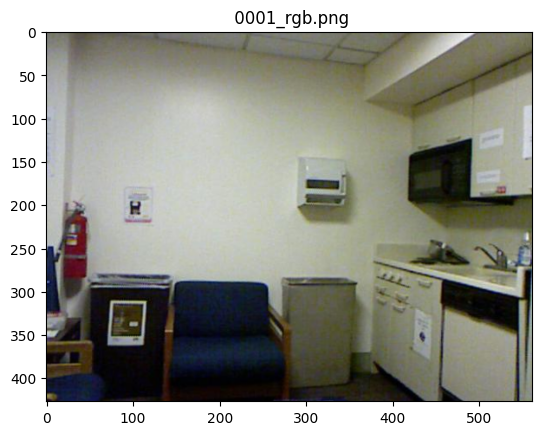

In [8]:
img = load_display_img(pth)

## SLIC

### n=5

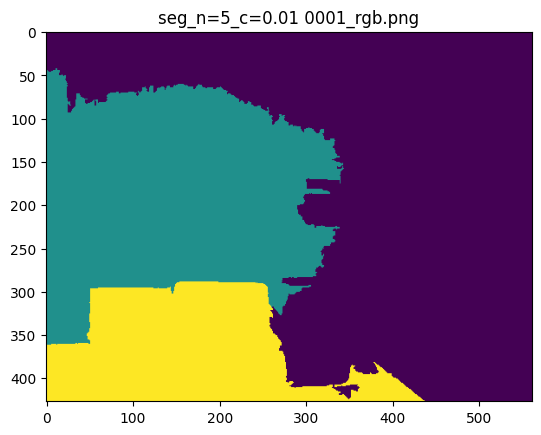

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1]])

In [9]:
segment(img, pth, 5, 0.01)

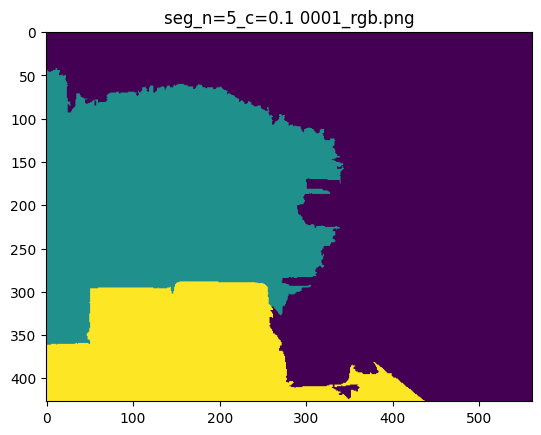

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1]])

In [10]:
segment(img, pth, 5, 0.1)

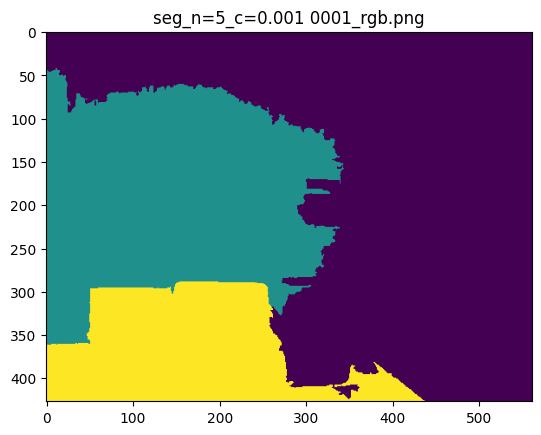

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1]])

In [11]:
segment(img, pth, 5, 0.001)

### n=3

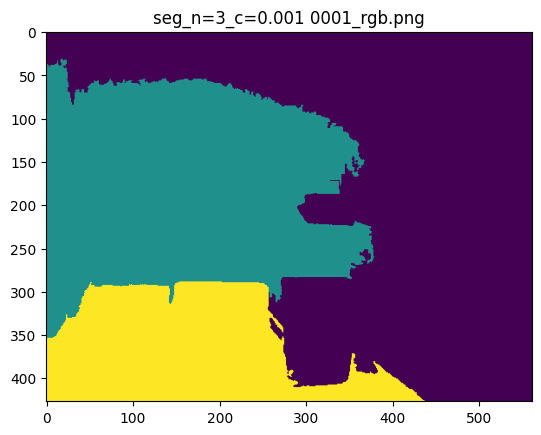

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1]])

In [12]:
segment(img, pth, 3, 0.001)

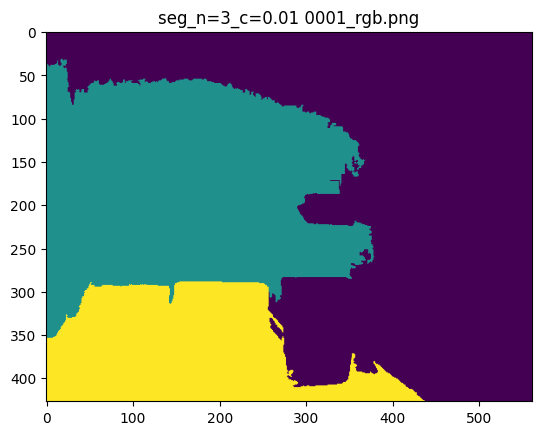

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1]])

In [13]:
segment(img, pth, 3, 0.01)

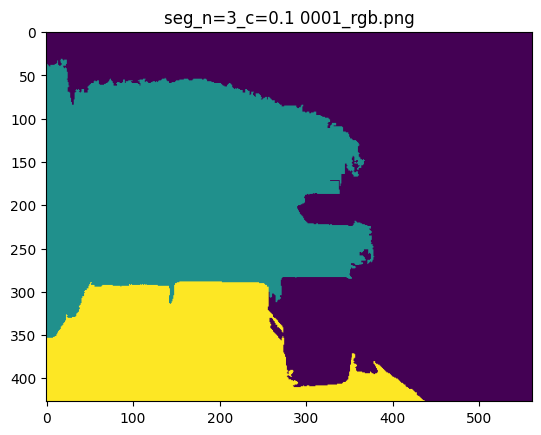

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1],
       [3, 3, 3, ..., 1, 1, 1]])

In [14]:
segment(img, pth, 3, 0.1)

### n=8

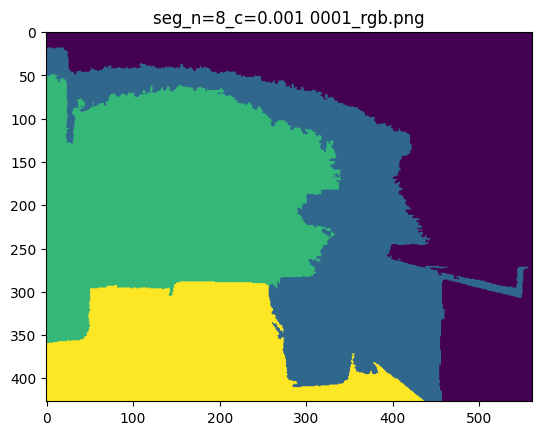

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [4, 4, 4, ..., 1, 1, 1],
       [4, 4, 4, ..., 1, 1, 1],
       [4, 4, 4, ..., 1, 1, 1]])

In [15]:
segment(img, pth, 8, 0.001)

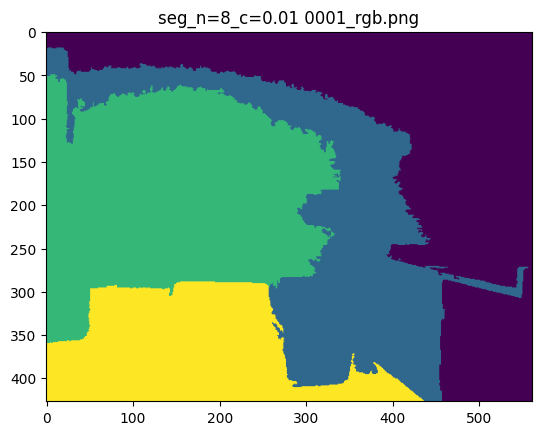

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [4, 4, 4, ..., 1, 1, 1],
       [4, 4, 4, ..., 1, 1, 1],
       [4, 4, 4, ..., 1, 1, 1]])

In [16]:
segment(img, pth, 8, 0.01)

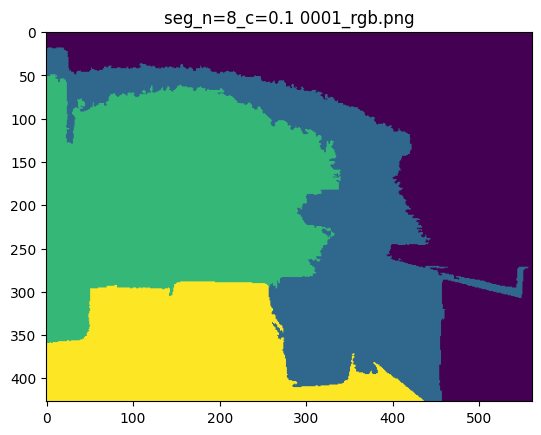

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [4, 4, 4, ..., 1, 1, 1],
       [4, 4, 4, ..., 1, 1, 1],
       [4, 4, 4, ..., 1, 1, 1]])

In [17]:
segment(img, pth, 8, 0.1)

### multiple variants

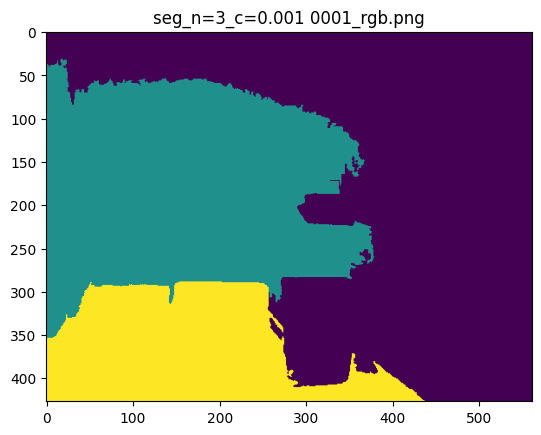

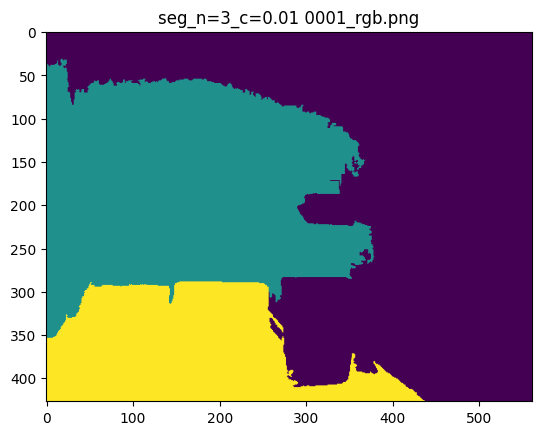

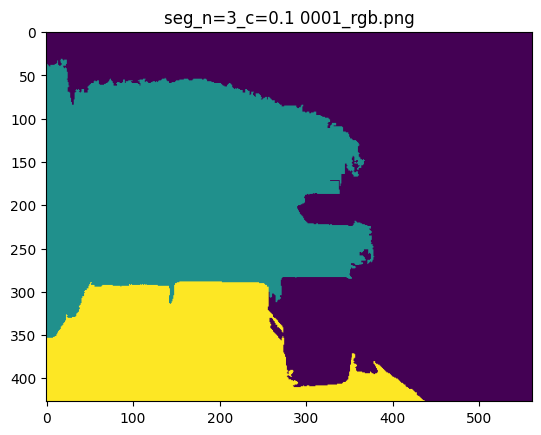

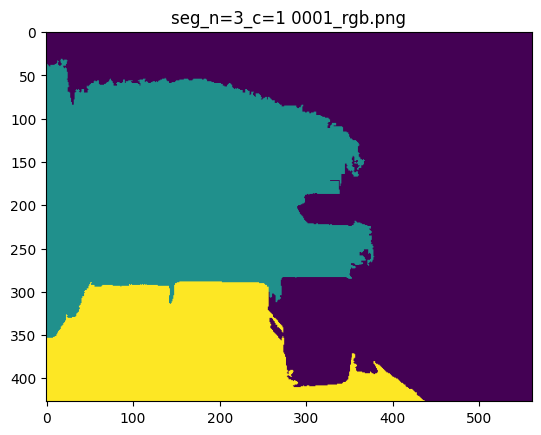

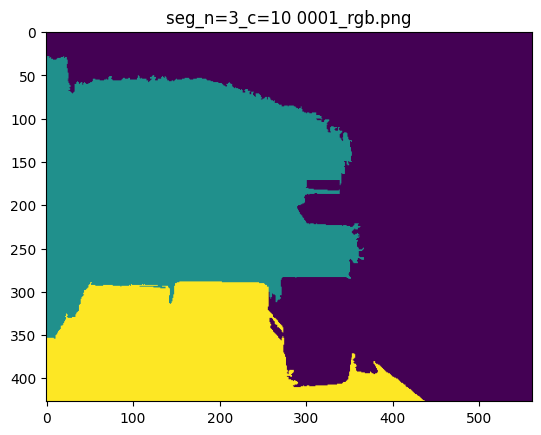

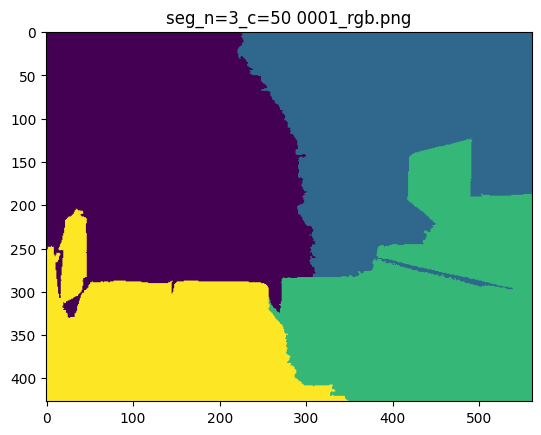

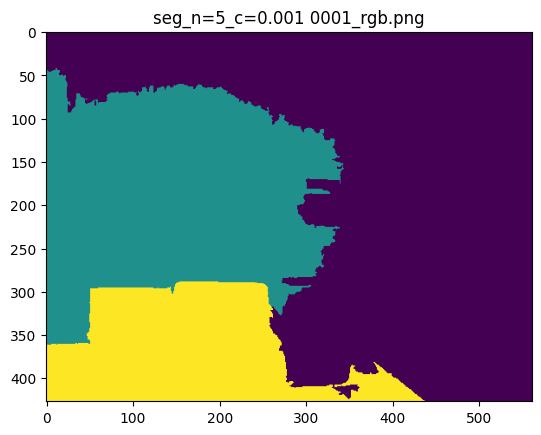

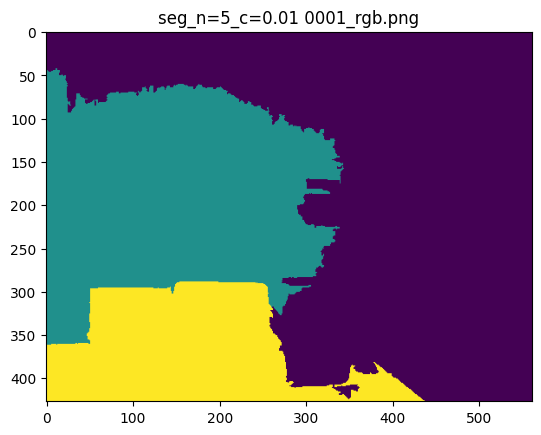

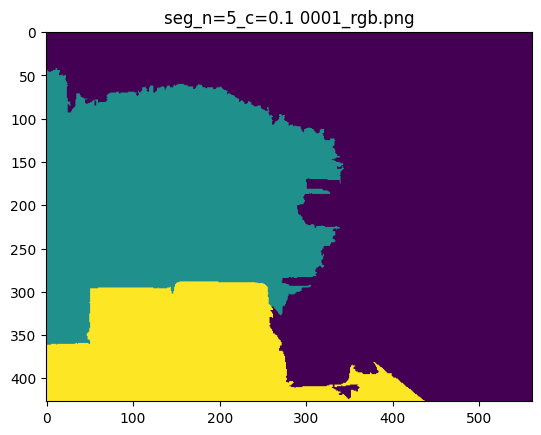

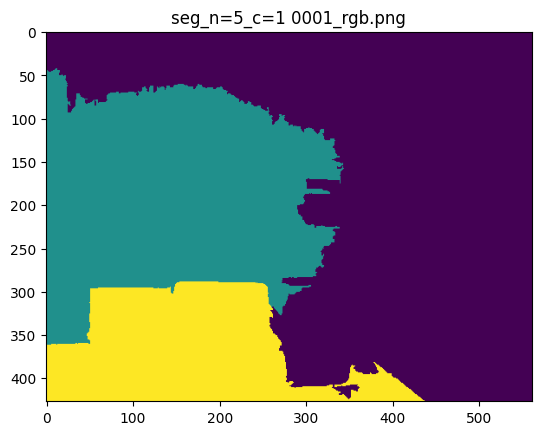

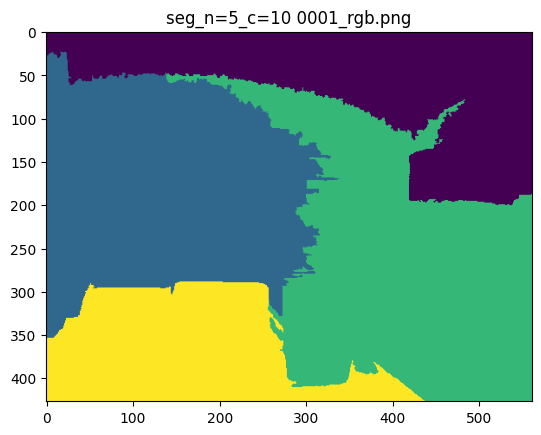

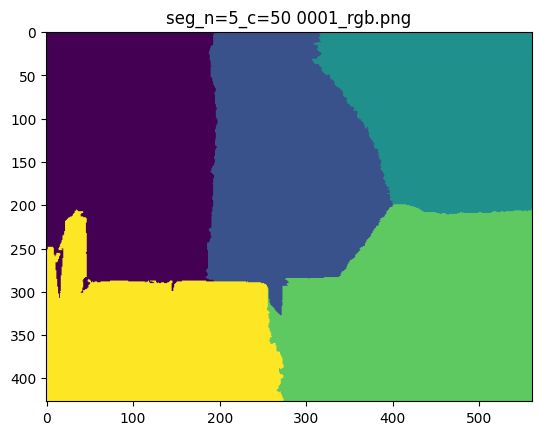

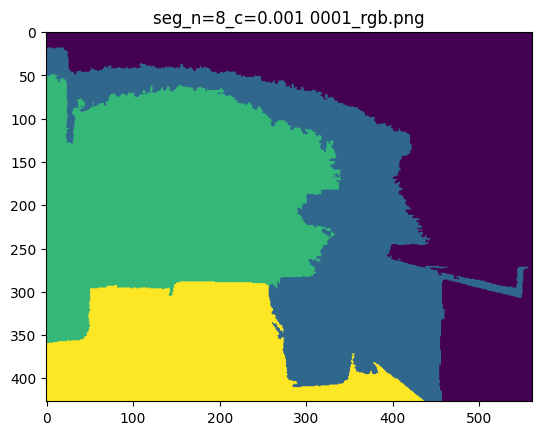

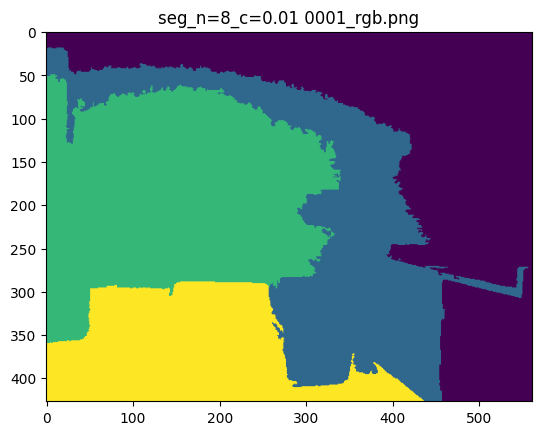

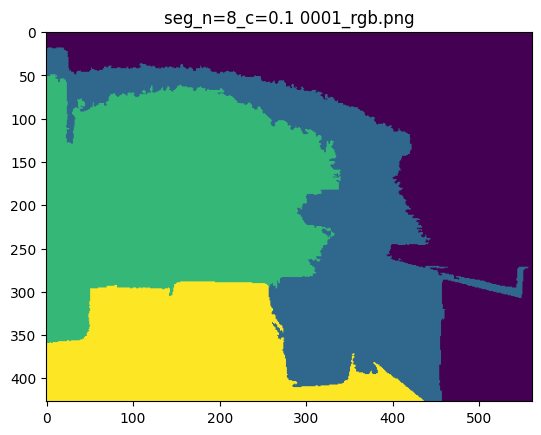

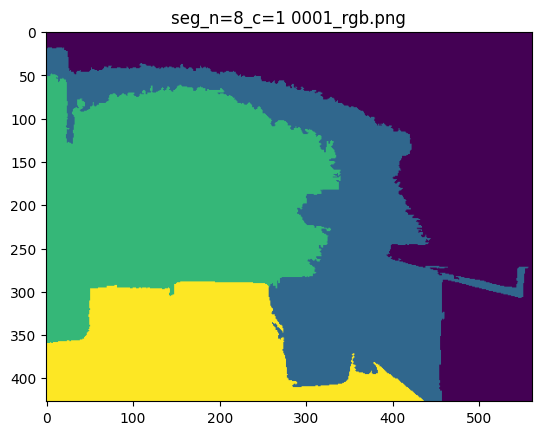

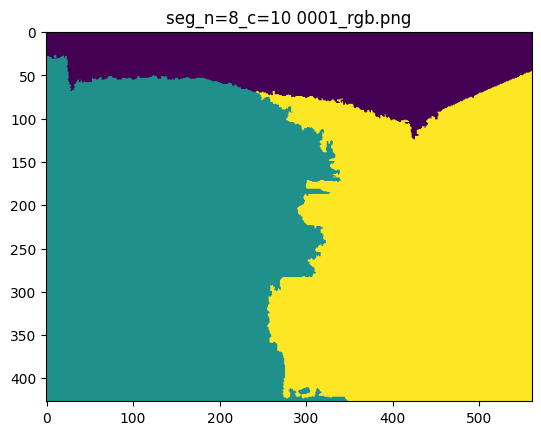

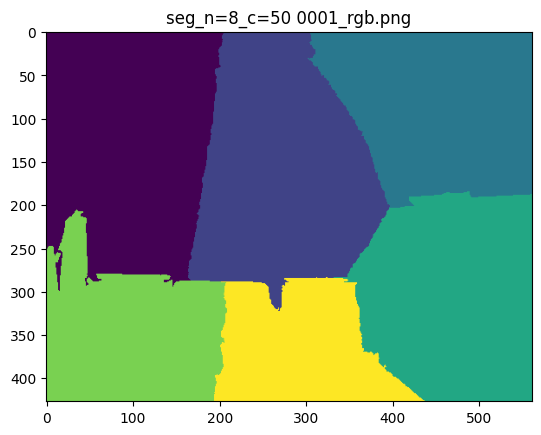

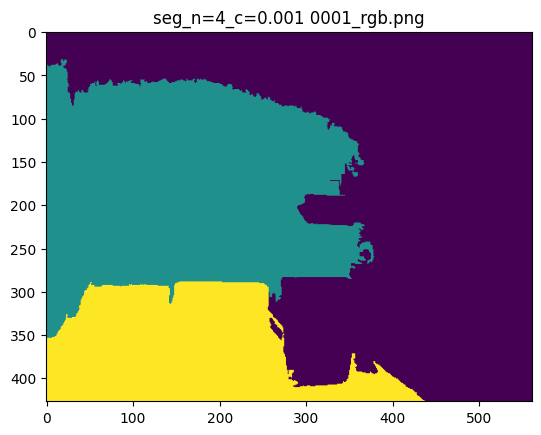

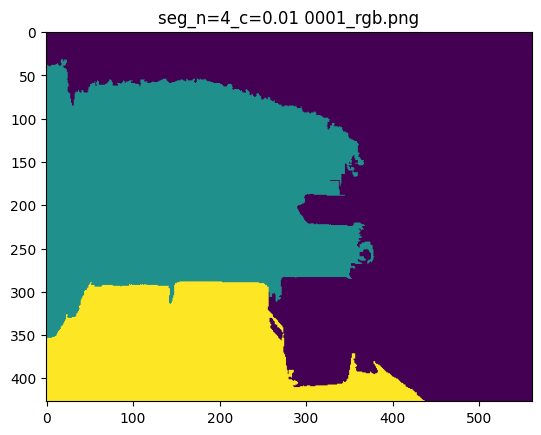

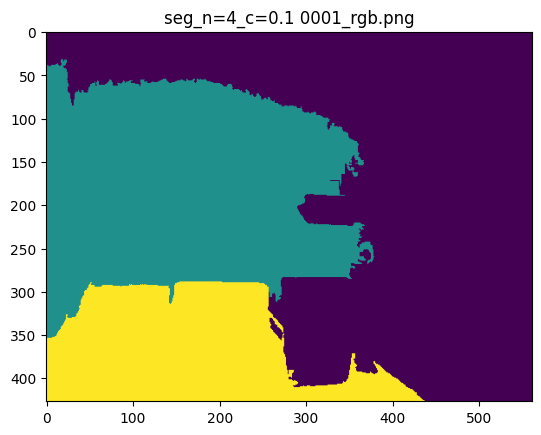

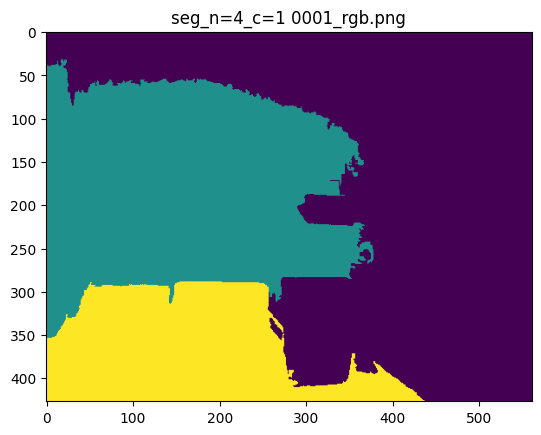

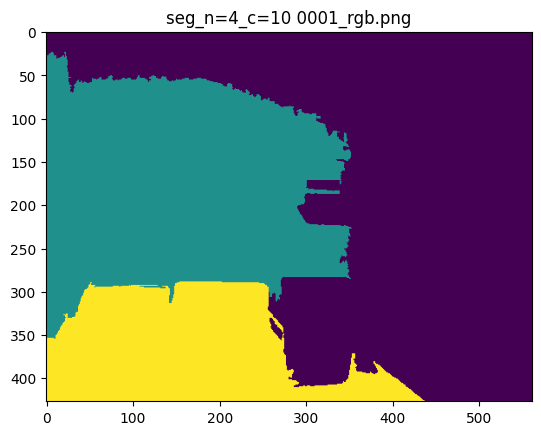

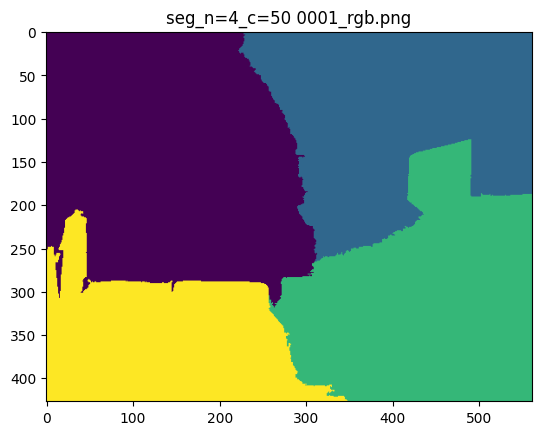

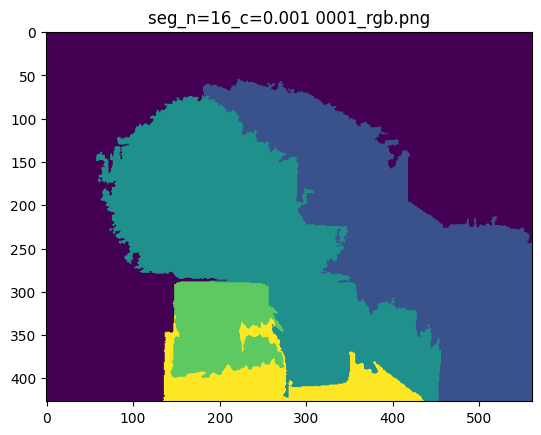

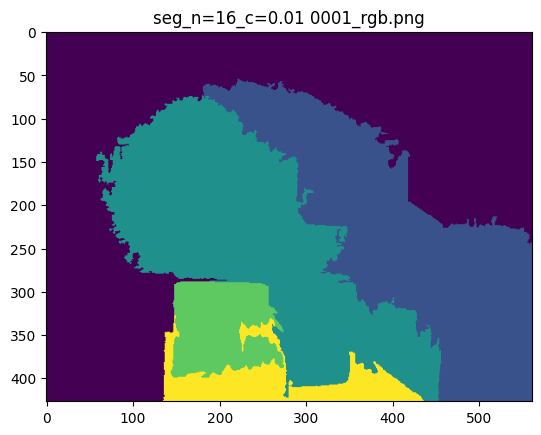

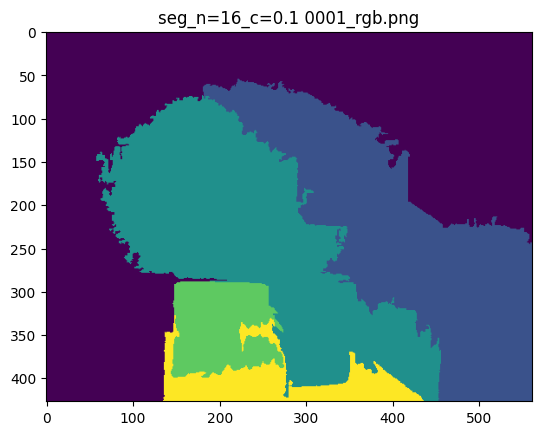

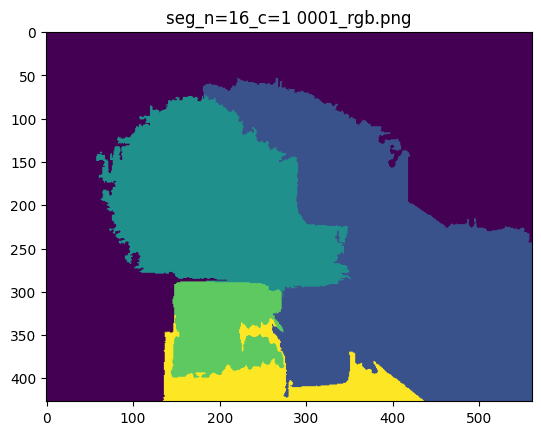

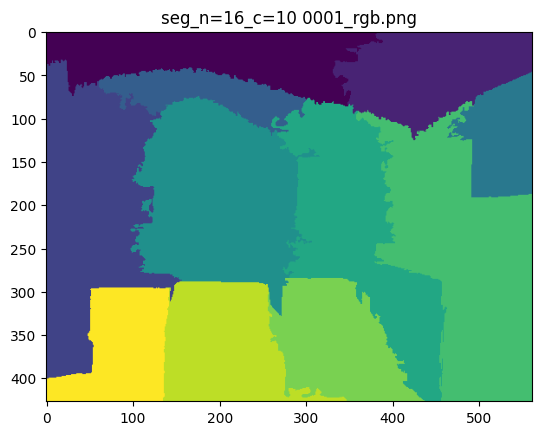

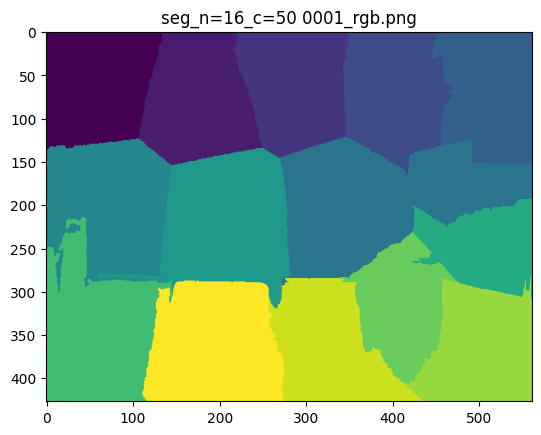

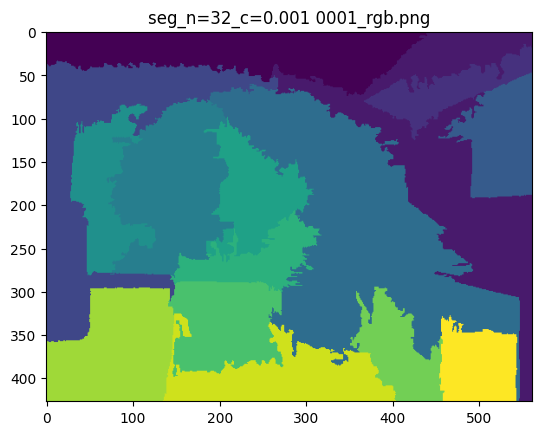

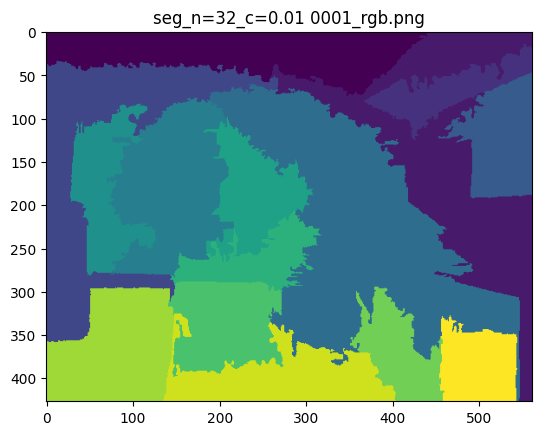

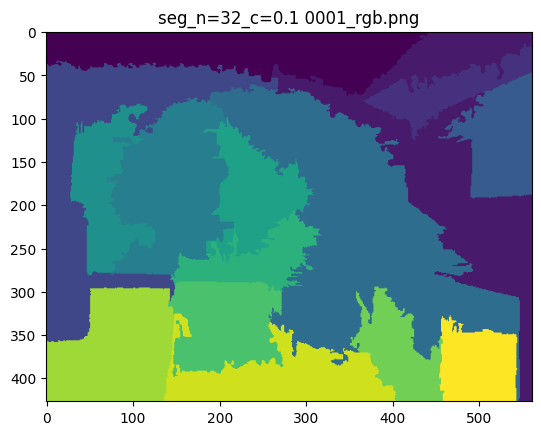

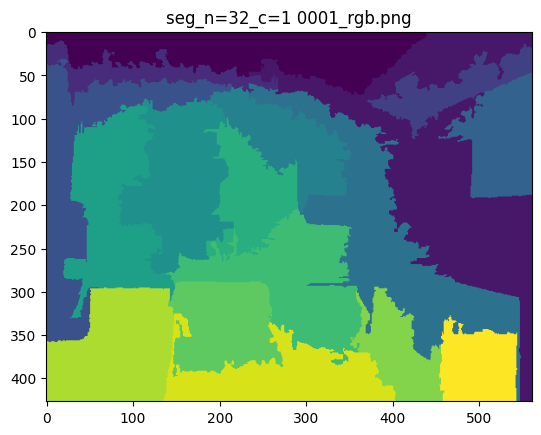

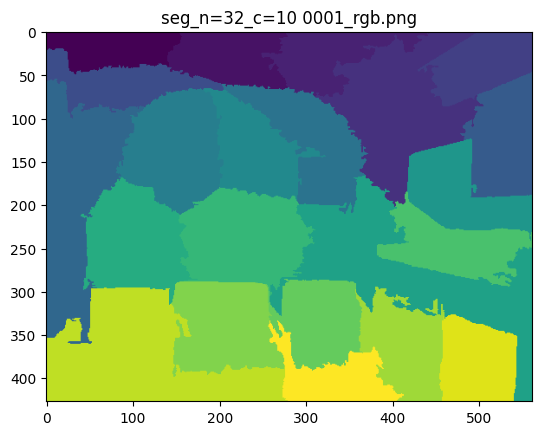

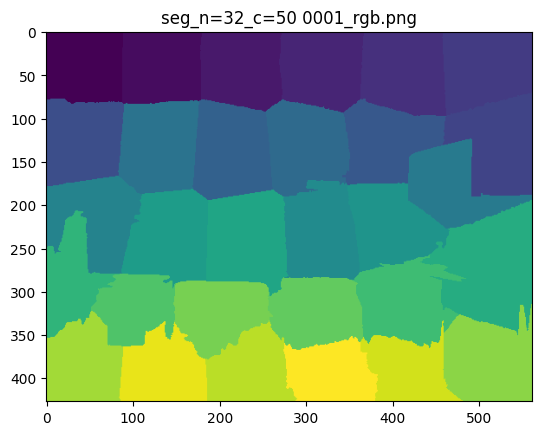

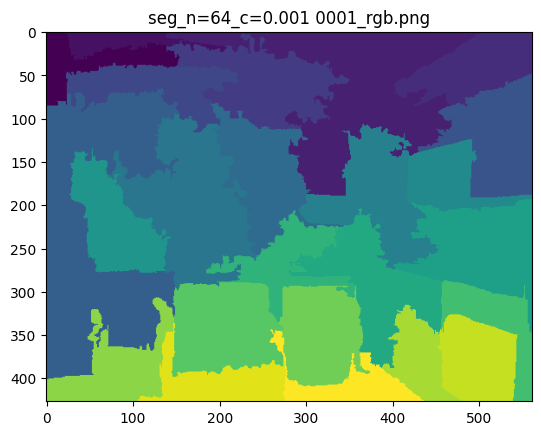

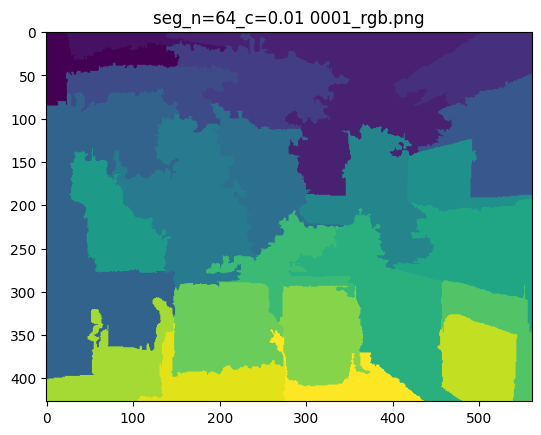

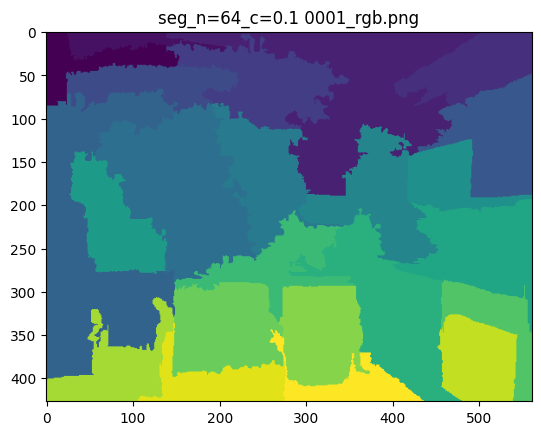

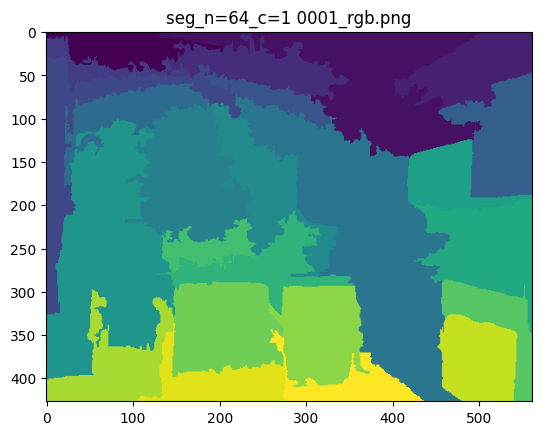

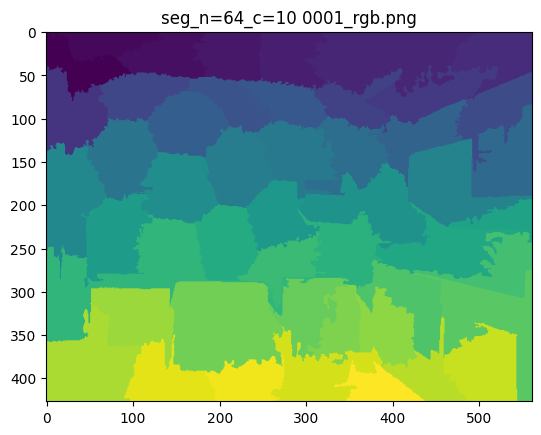

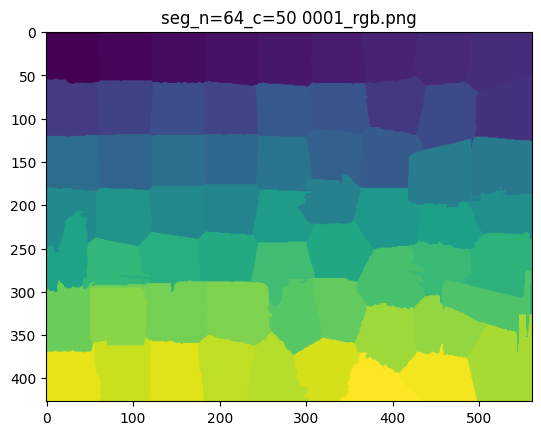

In [18]:
check_segments(img, pth, [3, 5, 8, 4, 16, 32, 64], [0.001, 0.01, 0.1, 1, 10, 50])

higher n and lower compactness look better

## gt

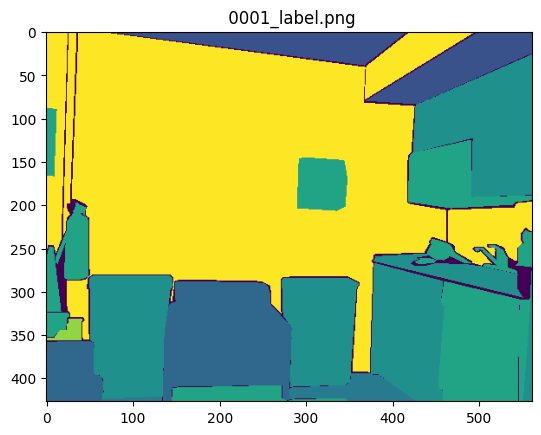

In [19]:
gt = load_display_img('0001_label.png')

In [20]:
gt

array([[12, 12, 12, ...,  3,  3,  3],
       [12, 12, 12, ...,  3,  3,  3],
       [12, 12, 12, ...,  3,  3,  3],
       ...,
       [ 4,  4,  4, ...,  6,  6,  6],
       [ 4,  4,  4, ...,  6,  6,  6],
       [ 4,  4,  4, ...,  6,  6,  6]], dtype=uint8)

In [21]:
np.unique(gt)

array([ 0,  3,  4,  5,  6,  7, 10, 12], dtype=uint8)

### n=8

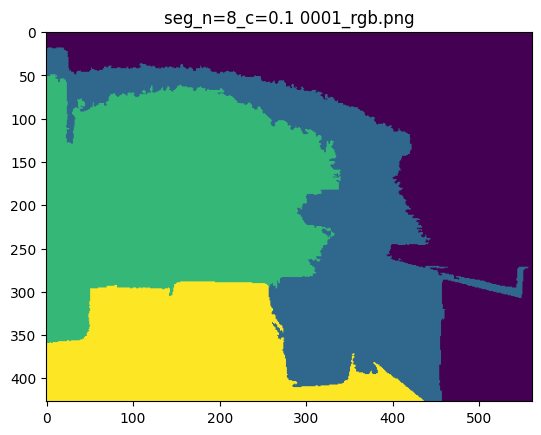

UE(G3) = 4.6517569598511415
UE(G4) = 6.7828131058549825
UE(G5) = 29.650675675675675
UE(G6) = 3.7542372881355934
UE(G7) = 6.9278196981731535
UE(G10) = 179.28257191201354
UE(G12) = 1.1074083523212133


33.1653261417179

In [22]:
ue(gt, segment(img, pth, 8, 0.1))

### n=32

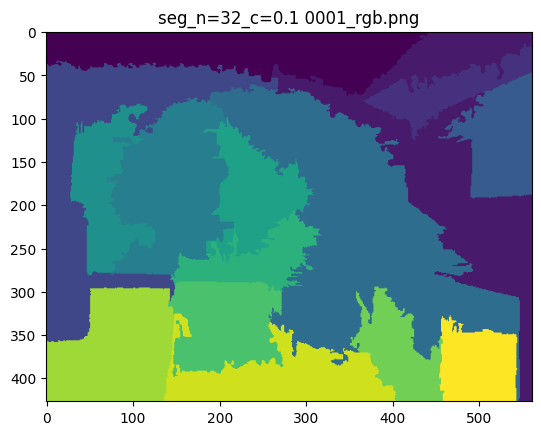

UE(G3) = 3.1183711443498177
UE(G4) = 4.754313687475766
UE(G5) = 11.191891891891892
UE(G6) = 2.5810741078871113
UE(G7) = 4.2849483717235906
UE(G10) = 66.99830795262267
UE(G12) = 0.9609392182565167


13.412835196315337

In [23]:
ue(gt, segment(img, pth, 8*4, 0.1))

### n=64

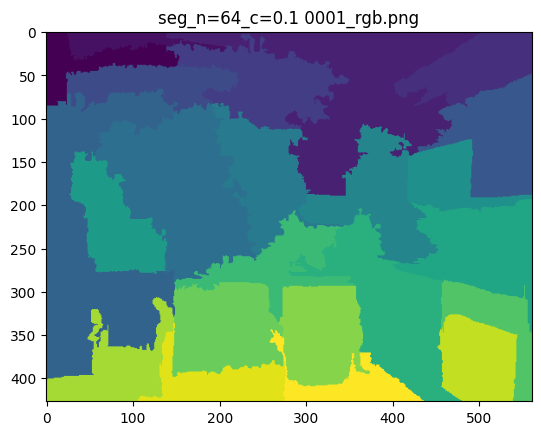

UE(G3) = 2.2964288270235453
UE(G4) = 2.5069309810003877
UE(G5) = 8.393918918918919
UE(G6) = 2.220914539753106
UE(G7) = 3.902303415409055
UE(G10) = 42.101522842639596
UE(G12) = 0.6769919679068171


8.871287356093061

In [24]:
ue(gt, segment(img, pth, 8*8, 0.1))

The average error decreases with increasing number of superpixels. More superpixels (on the same area) results in smaller pixels, so when wrong pxs intersect with gt, the area which is added is smaller. It works even though with smaller pxs there may be more different segments (so more different areas are included). But apparently, dealing with many small segments reduces the error.